In [3]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import cv2
import pandas as pd

In [4]:
DATASET_PATH = Path("dataset")

IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png"]

# Collect all images
image_files = [f for f in DATASET_PATH.glob("**/*") if f.suffix.lower() in IMAGE_EXTENSIONS]

# Collect all label files
label_files = list(DATASET_PATH.glob("**/*.txt"))

print(f"Total images: {len(image_files)}")
print(f"Total label files: {len(label_files)}")

Total images: 19486
Total label files: 19084


In [12]:
image_label_pairs = []

for img_path in image_files:
    
    # Convert image path → label path
    label_path = Path(str(img_path).replace("images", "labels")).with_suffix(".txt")
    
    if label_path.exists():
        image_label_pairs.append((img_path, label_path))

print(f"Matched image-label pairs: {len(image_label_pairs)}")

Matched image-label pairs: 18969


In [9]:
data = []

for img_path, label_path in image_label_pairs:
    with open(label_path, "r") as f:
        lines = f.readlines()
    
    for line in lines:
        values = line.strip().split()
        
        # Safety check
        if len(values) != 5:
            continue
        
        class_id, x, y, w, h = map(float, values)
        
        data.append({
            "image": img_path.name,
            "class_id": int(class_id),
            "x_center": x,
            "y_center": y,
            "width": w,
            "height": h
        })

df = pd.DataFrame(data)

print("Total annotations:", len(df))
df.head(20)

Total annotations: 70732


,image,class_id,x_center,y_center,width,height
0,152_14253.jpg,2,0.746826,0.669189,0.004395,0.021973
1,152_14253.jpg,2,0.743164,0.701660,0.014648,0.015625
2,152_14273.jpg,2,0.742432,0.640137,0.005371,0.019531
3,152_14273.jpg,2,0.735352,0.656494,0.016602,0.022949
4,152_14273.jpg,2,0.726807,0.693359,0.018066,0.024414
5,152_14293.jpg,2,0.727295,0.626953,0.015137,0.020508
6,152_14293.jpg,2,0.715088,0.643799,0.017090,0.022949
7,152_14293.jpg,2,0.706299,0.680664,0.018066,0.024414
8,152_14313.jpg,2,0.707764,0.613037,0.015137,0.020020
9,152_14313.jpg,2,0.695557,0.629883,0.017090,0.022461


In [8]:
print("Number of unique classes:", df["class_id"].nunique())

print("\nClass distribution:")
print(df["class_id"].value_counts())

print("\nBounding box statistics:")
print(df[["width", "height"]].describe())

Number of unique classes: 54

Class distribution:
class_id
27    16212
10     6497
24     3794
2      2742
16     2716
3      2394
30     2154
28     2110
6      1936
7      1854
43     1775
29     1665
9      1525
14     1419
1      1398
15     1384
46     1297
4      1281
8      1251
20     1207
41     1038
13      919
12      868
21      798
26      678
11      641
0       627
31      606
54      605
52      558
32      537
38      519
50      515
25      486
39      447
17      415
18      406
33      402
44      381
40      379
34      312
37      304
5       269
47      251
35      247
53      241
22      160
23      153
51      114
36      102
19       68
42       47
45       24
48        4
Name: count, dtype: int64

Bounding box statistics:
              width        height
count  70732.000000  70732.000000
mean       0.024564      0.023570
std        0.022515      0.014748
min        0.000000      0.000000
25%        0.017578      0.017090
50%        0.021973      0.021973
75%

Average objects per image: 3.7993231992265133


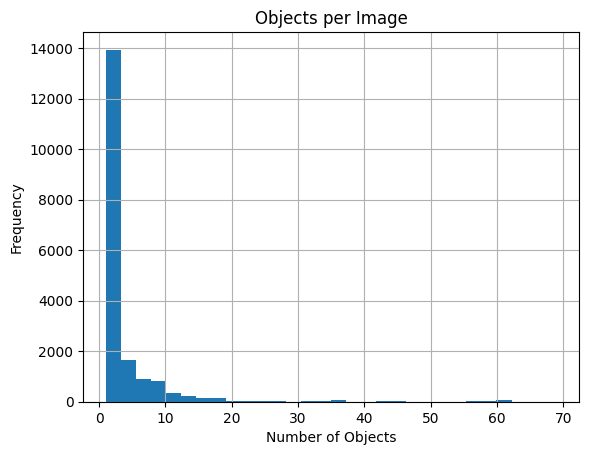

In [10]:
objects_per_image = df.groupby("image").size()

print("Average objects per image:", objects_per_image.mean())

import matplotlib.pyplot as plt

objects_per_image.hist(bins=30)
plt.title("Objects per Image")
plt.xlabel("Number of Objects")
plt.ylabel("Frequency")
plt.show()

In [11]:
import cv2
import matplotlib.pyplot as plt

def plot_image_with_boxes(img_path, label_path):
    image = cv2.imread(str(img_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    h_img, w_img, _ = image.shape
    
    with open(label_path, "r") as f:
        lines = f.readlines()
    
    for line in lines:
        values = line.strip().split()
        if len(values) != 5:
            continue
        
        _, x, y, w, h = map(float, values)
        
        # Convert YOLO → pixels
        x_center = x * w_img
        y_center = y * h_img
        w_box = w * w_img
        h_box = h * h_img
        
        x1 = int(x_center - w_box / 2)
        y1 = int(y_center - h_box / 2)
        x2 = int(x_center + w_box / 2)
        y2 = int(y_center + h_box / 2)
        
        cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)
    
    plt.imshow(image)
    plt.title(img_path.name)
    plt.axis("off")
    plt.show()

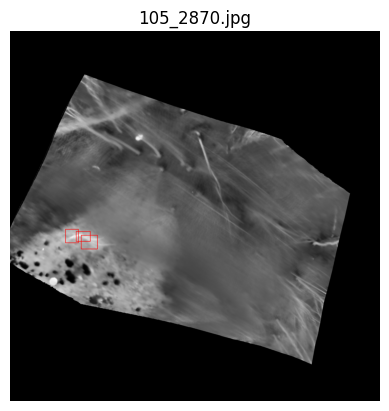

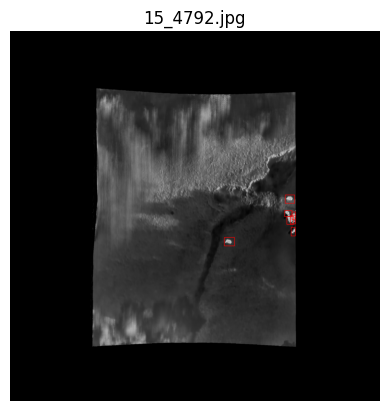

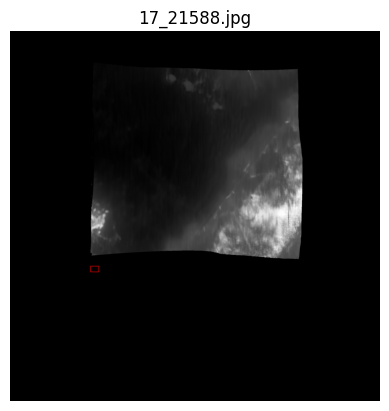

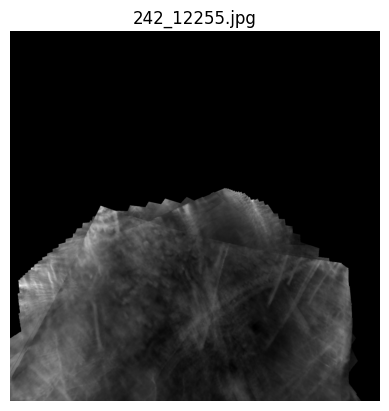

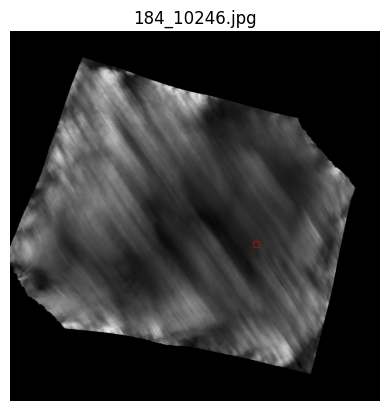

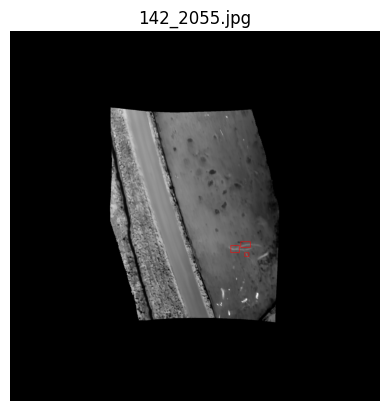

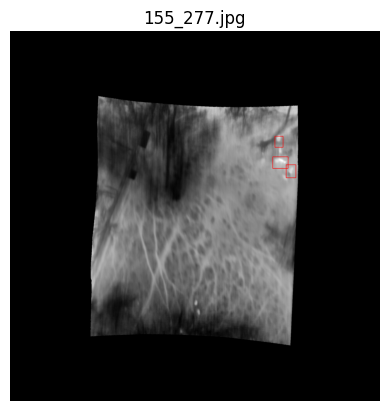

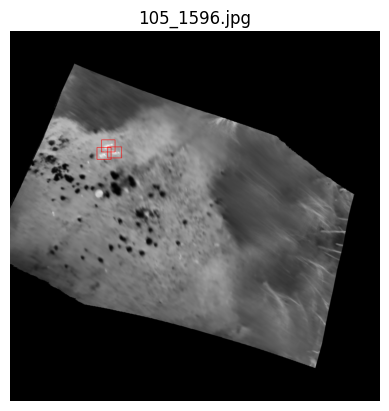

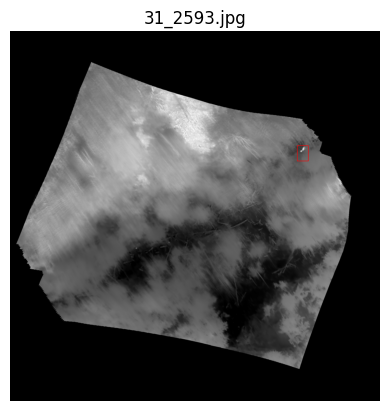

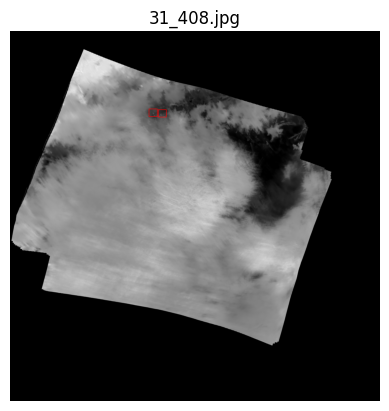

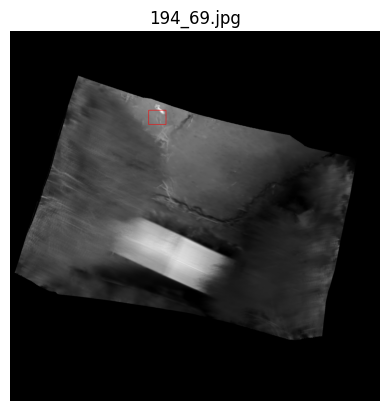

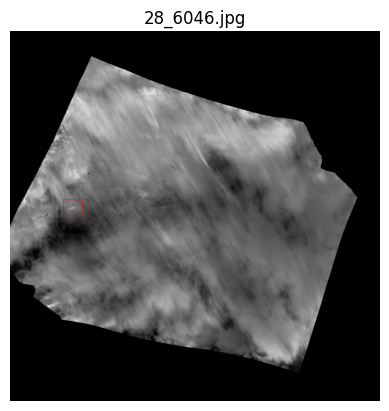

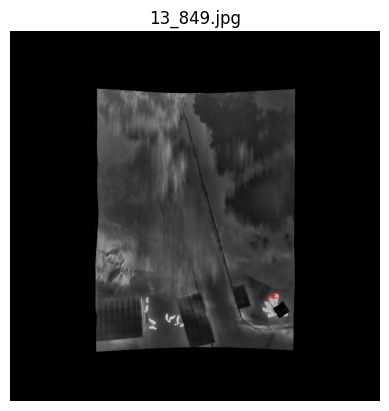

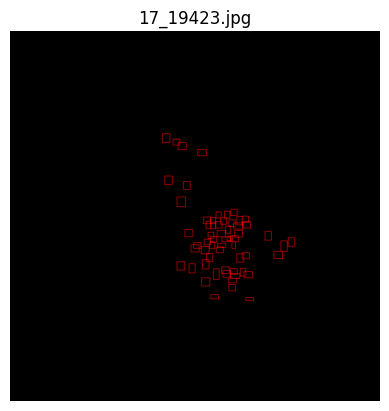

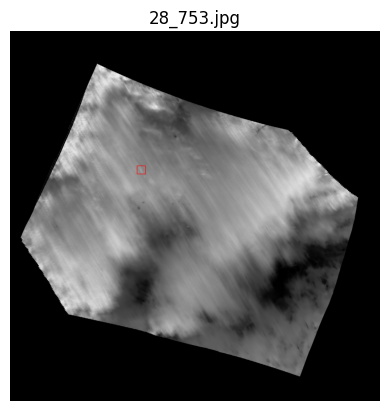

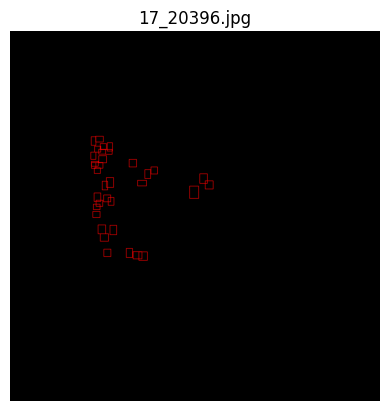

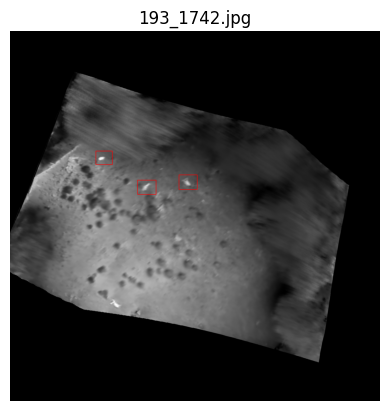

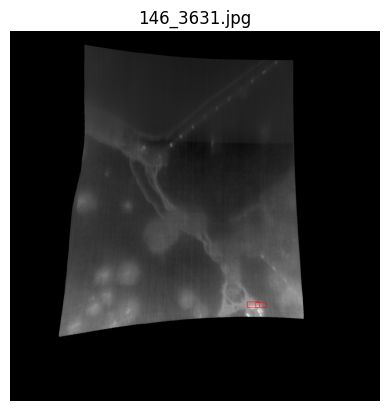

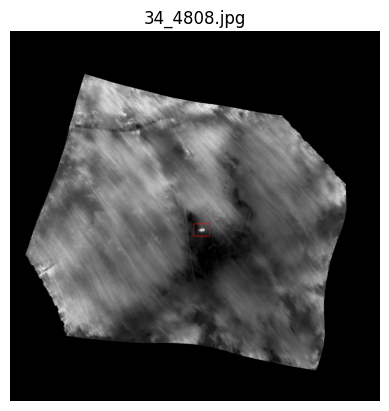

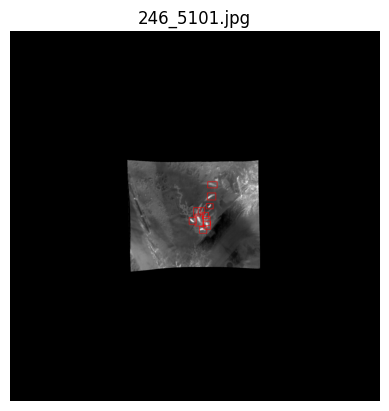

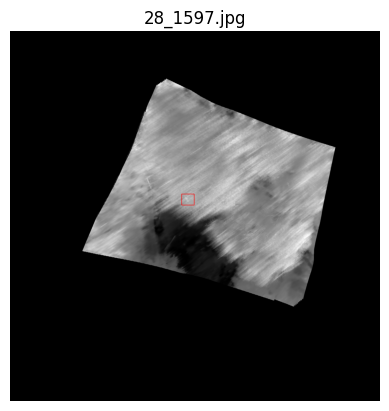

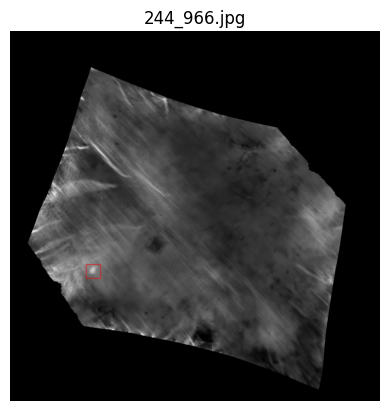

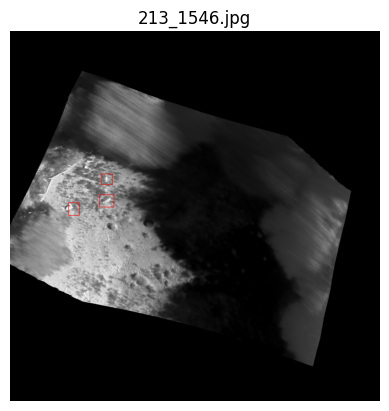

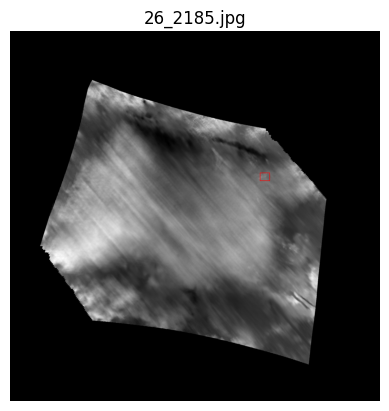

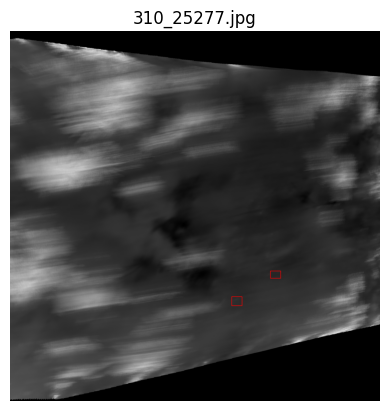

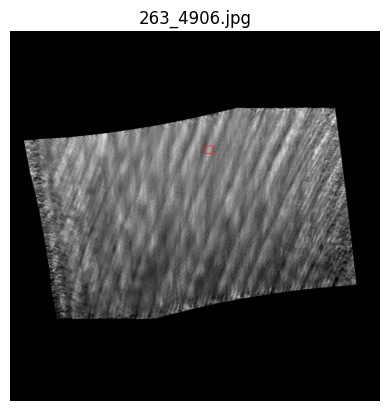

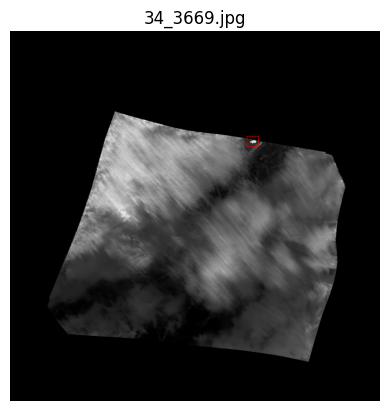

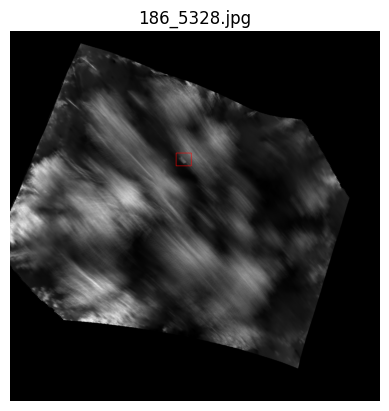

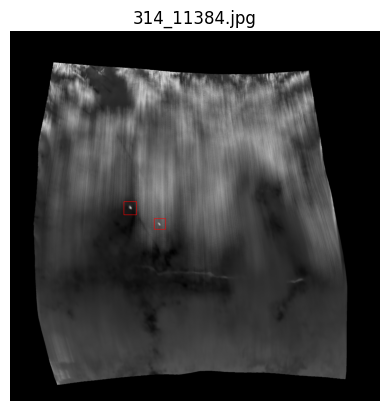

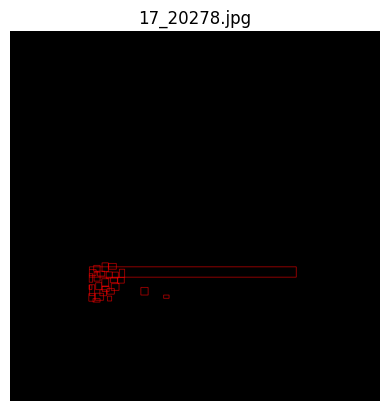

In [15]:
import random

samples = random.sample(image_label_pairs, 30)

for img_path, label_path in samples:
    plot_image_with_boxes(img_path, label_path)